# **ICU DB Merged - Balnced Optimization MODELING** 
------------------------------------
**Goal:** make a model that is optimized, regardless of realistic situations and see how that performs and what that means

### Summary: 
- Loaded the cleaned ICU dataset and kept only useful columns
-  Dropped duplicate / overly similar features (ex: kept APACHE score, removed acutephysiologyscore)
-  Identified numeric + categorical features and applied one-hot encoding
-  Split the data into Train (70%), Validation (15%), Test (15%)
-  Standardized (z-scored) the numeric features
-  Balanced the training set using SMOTE to fix class imbalance
-  Trained two models: Random Forest (RF) &  XGBoost (XGB)
-   Computed validation & test AUC to check initial model quality
-   Did threshold tuning (0.01-0.99) to find the best balance between recall, precision, and F1 instead of just maximizing one metric
-   Applied the best threshold to the test set to get final RF and XGB performance
-   Ran fairness checks for gender, ethnicity, and ICU type, comparing recall + precision across groups

### Key Findings:
- Compared RF vs XGB and found:
    - XGB gives more balanced precision/recall
    - RF is more “sensitive” but also noisier with more false positives
- Fairness gaps exist in both, especially for tiny subgroups
--------

In [35]:
# import/libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.metrics import precision_score, recall_score
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [3]:
target_col = "bad_outcome"

# load preprocessed data
df = pd.read_csv("ICUop_prep.csv")

print("Shape:", df.shape)

print("\nDtypes summary:\n", df.dtypes.value_counts())

print("\nAll columns & dtypes:\n")
display(df.dtypes.to_frame("dtype"))

print("\nTarget distribution:\n", df[target_col].value_counts(normalize=True))

print("\nTotal NaNs:", df.isna().sum().sum())

Shape: (2520, 127)

Dtypes summary:
 float64    118
object       8
int64        1
Name: count, dtype: int64

All columns & dtypes:



,dtype
gender,object
ethnicity,object
hospitalid,float64
unittype,object
admissionheight,float64
...,...
heartrate_max_log,float64
heartrate_std_log,float64
respiration_mean_log,float64
respiration_max_log,float64



Target distribution:
 bad_outcome
0    0.88373
1    0.11627
Name: proportion, dtype: float64

Total NaNs: 0


In [5]:
pd.set_option("display.max_rows", None)
display(df.dtypes.to_frame("dtype"))

,dtype
gender,object
ethnicity,object
hospitalid,float64
unittype,object
admissionheight,float64
admissionweight,float64
dischargeweight,float64
unitadmitsource,object
hospitaladmitsource,object
numbedscategory,object


In [7]:
# looking at cols and what to drop

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numeric cols:", len(num_cols))
print("\n\nCategorical cols:", len(cat_cols))
print("\n\nCategorical:", cat_cols)

Numeric cols: 118


Categorical cols: 8


Categorical: ['gender', 'ethnicity', 'unittype', 'unitadmitsource', 'hospitaladmitsource', 'numbedscategory', 'teachingstatus', 'region']


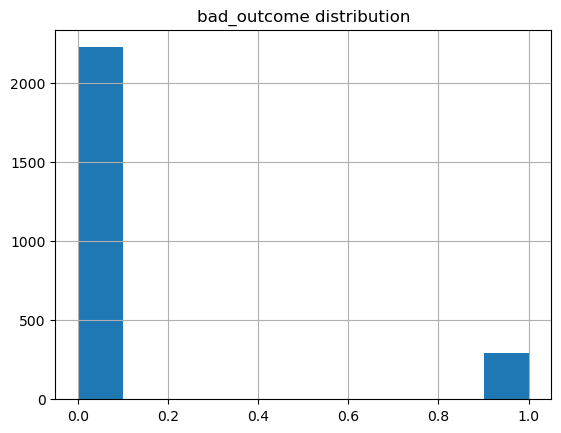

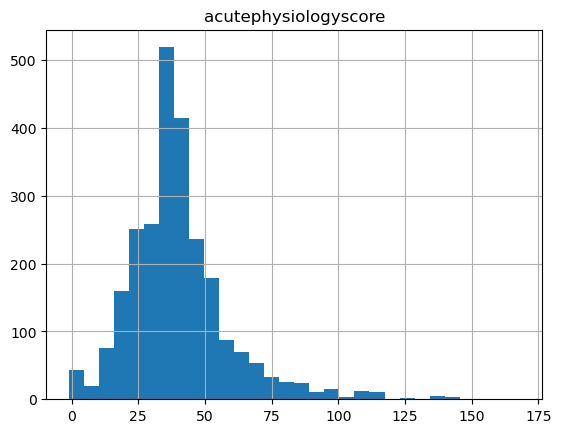

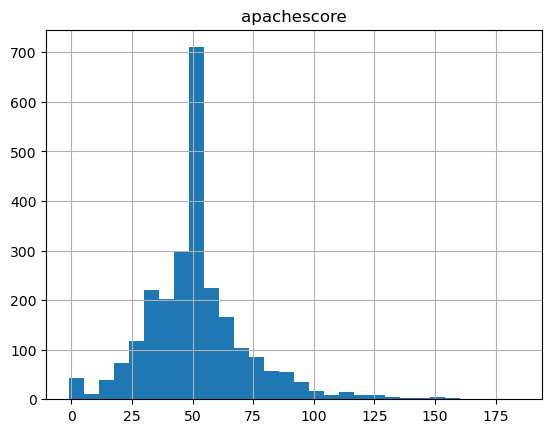

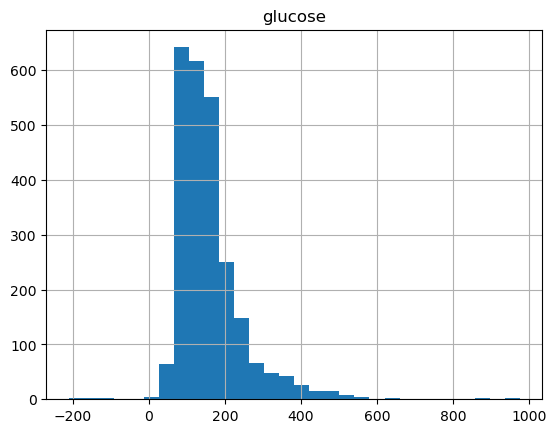

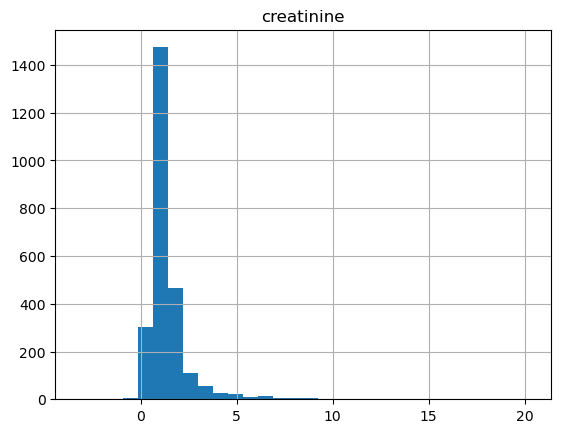

In [9]:
# quick distributions (just target and a few key features)
df[target_col].hist()
plt.title("bad_outcome distribution")
plt.show()

for col in ["acutephysiologyscore", "apachescore", "glucose", "creatinine"]:
    if col in df.columns:
        df[col].hist(bins=30)
        plt.title(col)
        plt.show()

In [11]:
# droppging acutephysiologyscore and only keeping apachescore
# APACHE score already includes the Acute Physiology Score 
# in the eICU database: apachescore = APACHE IVa score (final composite score) and acutephysiologyscore = APS component of APACHE
# highly correlated, and using both double-counts the same physiology information

df = df.drop(columns=["acutephysiologyscore"], errors="ignore")

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

print("Updated numeric cols:", len(num_cols))

Updated numeric cols: 117


In [13]:
# doing this to drop obviously useless/low-variance features

low_var_cols = []
for col in num_cols:
    if df[col].nunique() <= 1:
        low_var_cols.append(col)

print("Constant numeric cols:", low_var_cols)

Constant numeric cols: ['aids']


In [15]:
# also force-drop aids if still present
if "aids" in df.columns and "aids" not in low_var_cols:
    low_var_cols.append("aids")

print("Dropping:", low_var_cols)
df = df.drop(columns=low_var_cols)

# update num_cols
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]
print("Numeric cols after drop:", len(num_cols))

Dropping: ['aids']
Numeric cols after drop: 116


In [17]:
# making fairness columns and one-hot encode categoricals

# columns we will use later for subgroup fairness analysis
fairness_cols = ["gender", "ethnicity", "unittype"]

# keeping this separate for later merging w/ predictions
fair_df = df[fairness_cols + [target_col]].copy()

# one hot encode categorical columns for modeling
df_model = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Shape after get_dummies:", df_model.shape)

# X and y
X = df_model.drop(columns=[target_col])
y = df_model[target_col].astype(int)

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts(normalize=True))

Shape after get_dummies: (2520, 156)
X shape: (2520, 155)
y distribution:
 bad_outcome
0    0.88373
1    0.11627
Name: proportion, dtype: float64


-------
## **Split the Data 70/15/15**

In [19]:
# 70% of data: training (fit models + SMOTE)
# 15% of data: validation (pick thresholds / compare models)
# 15% of data: test (final unbiased performance)
# carry along fair_df so we can do fairness analysis later

# 1st split: TRAIN (70%) vs TEMP (30%)
X_train, X_temp, y_train, y_temp, fair_train, fair_temp = train_test_split(
    X,            
    y,           
    fair_df, # fairness cols (gender, ethnicity, unittype, bad_outcome)
    test_size=0.30, # 30% goes into TEMP, 70% stays in TRAIN
    random_state=42,     
    stratify=y # keep same class balance as og
)

# 2nd split: TEMP (30%), VAL (15%) & TEST (15%)
# split TEMP in half: 0.15 val & 0.15 test out of the original 1.0
X_val, X_test, y_val, y_test, fair_val, fair_test = train_test_split(
    X_temp,
    y_temp,
    fair_temp,
    test_size=0.50, # half of TEMP is TEST, other half is VAL
    random_state=42,
    stratify=y_temp # keep positive rate similar across VAL/TEST
)

# check: shapes & positive rate (mean of y)
print("Train:", X_train.shape, "pos rate:", y_train.mean())
print("Val:  ", X_val.shape,   "pos rate:", y_val.mean())
print("Test: ", X_test.shape,  "pos rate:", y_test.mean())

Train: (1764, 155) pos rate: 0.11621315192743764
Val:   (378, 155) pos rate: 0.1164021164021164
Test:  (378, 155) pos rate: 0.1164021164021164


## **Standardizing Features (Z-score)**

In [23]:
# fit scaler on TRAIN only ( no leak info from val/test)
# transform train, val, test w/ that scaler
# using the scaled versions for SMOTE + modeling

scaler = StandardScaler()

# fit on TRAIN features only
scaler.fit(X_train)

# transform ea split
X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# check
print("scaled shapes:")
print("train:", X_train_scaled.shape)
print("\nval:  ", X_val_scaled.shape)
print("\ntest: ", X_test_scaled.shape)

scaled shapes:
train: (1764, 155)

val:   (378, 155)

test:  (378, 155)


## **Apply SMOTE (only on TRAIN)**

In [26]:
sm = SMOTE(random_state=42, k_neighbors=5)

# fit & resample
X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)

print("before SMOTE:", X_train_scaled.shape, y_train.value_counts())
print("\nafter SMOTE:", X_train_sm.shape, y_train_sm.value_counts())

before SMOTE: (1764, 155) bad_outcome
0    1559
1     205
Name: count, dtype: int64

after SMOTE: (3118, 155) bad_outcome
0    1559
1    1559
Name: count, dtype: int64


-----------------

## **Train Random Forest (baseline)**

In [29]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight=None,   # keeping off bc already used SMOTE
    random_state=42,
    n_jobs=-1
)

# train on SMOTE-balanced, scaled TRAINING data
rf.fit(X_train_sm, y_train_sm)

# predict probabilities for threshold tuning later
rf_val_proba  = rf.predict_proba(X_val_scaled)[:, 1]
rf_test_proba = rf.predict_proba(X_test_scaled)[:, 1]

print("RF Validation AUC:", roc_auc_score(y_val, rf_val_proba))
print("\nRF Test AUC:", roc_auc_score(y_test, rf_test_proba))

RF Validation AUC: 0.786880783886772

RF Test AUC: 0.8350571584104518


## **Train XGBoost (baseline)**

In [32]:
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=4, # moderate depth (to avoid overfitting)
    learning_rate=0.05, # slower learning for more stable performance
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# train on SMOTE-balanced, scaled TRAINING data
xgb.fit(X_train_sm, y_train_sm)

# predict probabilities for val & test
xgb_val_proba  = xgb.predict_proba(X_val_scaled)[:, 1]
xgb_test_proba = xgb.predict_proba(X_test_scaled)[:, 1]

# auc scores
print("XGB Val AUC:",  roc_auc_score(y_val,  xgb_val_proba))
print("\nXGB Test AUC:", roc_auc_score(y_test, xgb_test_proba))

XGB Val AUC: 0.7979722373434949

XGB Test AUC: 0.8336962438758846


----------
## **Threshold Tuning  (balance recall & precision via F1) for BOTH RF & XGB**

In [38]:
# function to sweep thresholds and compute metrics 
def sweep_thresholds(y_true, y_proba):
    thresholds = np.linspace(0.01, 0.99, 99)
    rows = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        rec = recall_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        rows.append((t, rec, prec, f1))
    return np.array(rows) # columns: [thr, recall, precision, f1]


# pick "balanced" threshold (max F1, tie-break by recall)
def choose_threshold_balance(y_true, y_proba):
    metrics = sweep_thresholds(y_true, y_proba)
    thrs = metrics[:, 0]
    recs = metrics[:, 1]
    precs = metrics[:, 2]
    f1s = metrics[:, 3]

    best_idx = 0
    for i in range(1, len(thrs)):
        better_f1 = f1s[i] > f1s[best_idx]
        similar_f1 = np.isclose(f1s[i], f1s[best_idx], atol=0.01)
        better_recall = recs[i] > recs[best_idx]

        # main goal: higher F1; if F1 ~ same, prefer higher recall
        if better_f1 or (similar_f1 and better_recall):
            best_idx = i

    best = {
        "thr": float(thrs[best_idx]),
        "recall": float(recs[best_idx]),
        "precision": float(precs[best_idx]),
        "f1": float(f1s[best_idx]),
    }
    return best, metrics


# plot confusion matrix
def plot_confusion(y_true, y_pred, title="Confusion matrix"):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots()
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, int(v), ha="center", va="center")
    fig.colorbar(im, ax=ax)
    plt.show()

RF best balanced threshold: {'thr': 0.36000000000000004, 'recall': 0.6363636363636364, 'precision': 0.34146341463414637, 'f1': 0.4444444444444444}

RF validation report (balanced threshold):
              precision    recall  f1-score   support

           0      0.946     0.838     0.889       334
           1      0.341     0.636     0.444        44

    accuracy                          0.815       378
   macro avg      0.644     0.737     0.667       378
weighted avg      0.876     0.815     0.837       378



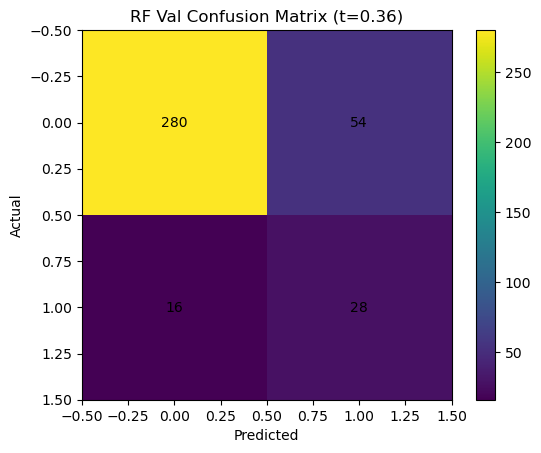

In [40]:
# run the tuning for RF
rf_best, rf_metrics = choose_threshold_balance(y_val.values, rf_val_proba)
print("RF best balanced threshold:", rf_best)

rf_val_pred_best = (rf_val_proba >= rf_best["thr"]).astype(int)
print("\nRF validation report (balanced threshold):")
print(classification_report(y_val, rf_val_pred_best, digits=3))
plot_confusion(y_val, rf_val_pred_best,
               title=f"RF Val Confusion Matrix (t={rf_best['thr']:.2f})")


XGB best balanced threshold: {'thr': 0.21000000000000002, 'recall': 0.5681818181818182, 'precision': 0.3787878787878788, 'f1': 0.45454545454545453}

XGB validation report (balanced threshold):
              precision    recall  f1-score   support

           0      0.939     0.877     0.907       334
           1      0.379     0.568     0.455        44

    accuracy                          0.841       378
   macro avg      0.659     0.723     0.681       378
weighted avg      0.874     0.841     0.854       378



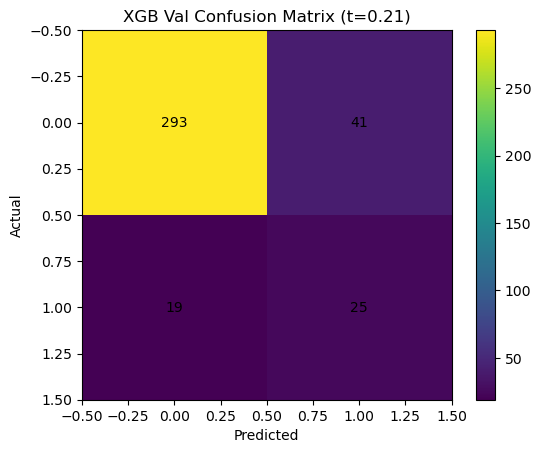

In [42]:
# run tuning for XGB
xgb_best, xgb_metrics = choose_threshold_balance(y_val.values, xgb_val_proba)
print("\nXGB best balanced threshold:", xgb_best)

xgb_val_pred_best = (xgb_val_proba >= xgb_best["thr"]).astype(int)
print("\nXGB validation report (balanced threshold):")
print(classification_report(y_val, xgb_val_pred_best, digits=3))
plot_confusion(y_val, xgb_val_pred_best,
               title=f"XGB Val Confusion Matrix (t={xgb_best['thr']:.2f})")

notes:

**RF (t = 0.36):**
- recall (class 1) = 0.64
- precision ≈ 0.34
- f1 ≈ 0.44
- catches more positives, but with more false pos

**XGB (t = 0.21):**
- recall = 0.57
- precision = 0.38
- f1 = 0.45
- slightly fewer true positives, but cleaner (higher precision) and slightly better f1

--------

## **Evaluate RF vs XGB on the test set using the balanced thresholds**

In [46]:
def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4,4))
    im = ax.imshow(cm, interpolation='nearest')
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(cm.shape[1]),
        yticks=np.arange(cm.shape[0]),
        xticklabels=[0,1],
        yticklabels=[0,1],
        xlabel='Predicted',
        ylabel='Actual',
        title=title
    )
    # write counts
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j],
                    ha="center", va="center")
    plt.tight_layout()
    plt.show()

RF Test (balanced threshold)
RF best threshold: 0.36

              precision    recall  f1-score   support

           0      0.936     0.871     0.902       334
           1      0.358     0.545     0.432        44

    accuracy                          0.833       378
   macro avg      0.647     0.708     0.667       378
weighted avg      0.868     0.833     0.848       378



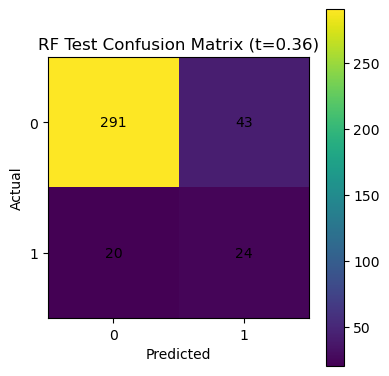

In [48]:
# RF on TEST (balanced threshold)
rf_best_thr = rf_best["thr"]
rf_test_pred_best = (rf_test_proba >= rf_best_thr).astype(int)

print("RF Test (balanced threshold)")
print(f"RF best threshold: {rf_best_thr:.2f}\n")
print(classification_report(y_test, rf_test_pred_best, digits=3))
plot_confusion(y_test, rf_test_pred_best,
               title=f"RF Test Confusion Matrix (t={rf_best_thr:.2f})")

XGB Test (balanced threshold)
XGB best threshold: 0.21

              precision    recall  f1-score   support

           0      0.927     0.913     0.920       334
           1      0.408     0.455     0.430        44

    accuracy                          0.860       378
   macro avg      0.668     0.684     0.675       378
weighted avg      0.867     0.860     0.863       378



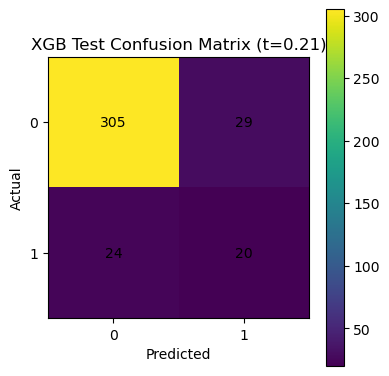

In [50]:
# XGB on TEST (balanced threshold) 
xgb_best_thr = xgb_best["thr"]
xgb_test_pred_best = (xgb_test_proba >= xgb_best_thr).astype(int)

print("XGB Test (balanced threshold)")
print(f"XGB best threshold: {xgb_best_thr:.2f}\n")
print(classification_report(y_test, xgb_test_pred_best, digits=3))
plot_confusion(y_test, xgb_test_pred_best,
               title=f"XGB Test Confusion Matrix (t={xgb_best_thr:.2f})")

notes: 

**RF (t = 0.36):**
- recall (positive class): 0.545
- precision (positive class): 0.358
- f1: 0.432
- AUC: 0.835
- CM:TP=24, FN=20, FP=43, TN=291


**XGBoost (t = 0.21)**
- recall (positive class): 0.455
- precision (positive class): 0.408
- f1: 0.430
- AUC: 0.834
- CM: TP=20, FN=24, FP=29, TN=305

### **Comparision**
1. Recall (catching positives)
- RF catches more true positives (24 vs 20)
- So RF performs better if missing high-risk cases is dangerous

2. Precision (how many predicted positives are correct)
- XGB has slightly higher precision (0.408 vs 0.358)
- XGB makes fewer false alarms

3. AUC (overall ranking ability)
- RF: 0.835 & XGB: 0.834, are basically identical

4. F1-score
- RF: 0.432 & XGB: 0.430, also too close to matter.

5. Confusion Matrix trade-offs
- RF has more FP (43), more false alarms
- XGB has more FN (24), this misses more high-risk patients

### **HMM what is the goal?** 
- If the goal is “catch more real bad outcomes”: RF
- If the goal is “fewer false alarms”: XGB
- Both have almost identical AUC/F1, the main difference is recall vs precision


-------

## **Fairness Analysis (Gender, Ethnicity, Unittype)**

In [58]:
def subgroup_metrics(y_true, y_pred, group_values):
    rows = []
    df = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred,
        "group": group_values
    })

    for g, sub in df.groupby("group"):
        tp = ((sub["y_pred"] == 1) & (sub["y_true"] == 1)).sum()
        fp = ((sub["y_pred"] == 1) & (sub["y_true"] == 0)).sum()
        fn = ((sub["y_pred"] == 0) & (sub["y_true"] == 1)).sum()
        tn = ((sub["y_pred"] == 0) & (sub["y_true"] == 0)).sum()

        recall = tp / (tp + fn + 1e-8)
        precision = tp / (tp + fp + 1e-8)

        rows.append({
            "group": g,
            "n": len(sub),
            "recall": round(recall, 3),
            "precision": round(precision, 3),
            "TP": tp, "FP": fp, "FN": fn, "TN": tn
        })

    return pd.DataFrame(rows)

In [60]:
# RF predictions using balanced threshold
rf_thr = rf_best["thr"]
rf_test_pred_best = (rf_test_proba >= rf_thr).astype(int)

# XGB predictions using balanced threshold
xgb_thr = xgb_best["thr"]
xgb_test_pred_best = (xgb_test_proba >= xgb_thr).astype(int)

In [62]:
print("\nFairness: Random Forest\n")

for col in ["gender", "ethnicity", "unittype"]:
    print(f"\nFairness by {col.upper()} (RF):\n")
    display(subgroup_metrics(
        y_true = y_test.values,
        y_pred = rf_test_pred_best,
        group_values = fair_test[col].values
    ))


Fairness: Random Forest


Fairness by GENDER (RF):



,group,n,recall,precision,TP,FP,FN,TN
0,Female,126,0.526,0.476,10,11,9,96
1,Male,252,0.560,0.304,14,32,11,195



Fairness by ETHNICITY (RF):



,group,n,recall,precision,TP,FP,FN,TN
0,African American,37,0.250,0.333,1,2,3,31
1,Caucasian,296,0.594,0.333,19,38,13,226
2,Hispanic,22,0.750,0.600,3,2,1,16
3,Other,7,0.000,0.000,0,0,1,6
4,Other/Unknown,13,0.333,0.500,1,1,2,9
5,Unknown,3,0.000,0.000,0,0,0,3



Fairness by UNITTYPE (RF):



,group,n,recall,precision,TP,FP,FN,TN
0,CCU-CTICU,7,1.000,0.500,1,1,0,5
1,CSICU,17,1.000,1.000,1,0,0,16
2,CTICU,4,0.000,0.000,0,1,0,3
3,Cardiac ICU,20,0.667,0.500,2,2,1,15
4,MICU,22,1.000,0.250,2,6,0,14
5,Med-Surg ICU,282,0.531,0.354,17,31,15,219
6,Neuro ICU,14,0.250,0.500,1,1,3,9
7,SICU,12,0.000,0.000,0,1,1,10


In [64]:
print("\nFairness: XGBoost\n")

for col in ["gender", "ethnicity", "unittype"]:
    print(f"\nFairness by {col.upper()} (XGB):\n")
    display(subgroup_metrics(
        y_true = y_test.values,
        y_pred = xgb_test_pred_best,
        group_values = fair_test[col].values
    ))


Fairness: XGBoost


Fairness by GENDER (XGB):



,group,n,recall,precision,TP,FP,FN,TN
0,Female,126,0.421,0.400,8,12,11,95
1,Male,252,0.480,0.414,12,17,13,210



Fairness by ETHNICITY (XGB):



,group,n,recall,precision,TP,FP,FN,TN
0,African American,37,0.25,0.500,1,1,3,32
1,Caucasian,296,0.50,0.372,16,27,16,237
2,Hispanic,22,0.75,1.000,3,0,1,18
3,Other,7,0.00,0.000,0,1,1,5
4,Other/Unknown,13,0.00,0.000,0,0,3,10
5,Unknown,3,0.00,0.000,0,0,0,3



Fairness by UNITTYPE (XGB):



,group,n,recall,precision,TP,FP,FN,TN
0,CCU-CTICU,7,0.000,0.000,0,1,1,5
1,CSICU,17,0.000,0.000,0,0,1,16
2,CTICU,4,0.000,0.000,0,0,0,4
3,Cardiac ICU,20,0.667,0.500,2,2,1,15
4,MICU,22,0.500,0.167,1,5,1,15
5,Med-Surg ICU,282,0.531,0.472,17,19,15,231
6,Neuro ICU,14,0.000,0.000,0,1,4,9
7,SICU,12,0.000,0.000,0,1,1,10


In [79]:
import matplotlib.pyplot as plt

def plot_fairness_bars(model_name, y_true, y_pred, fair_df, group_col):
    # get metrics table
    metrics_df = subgroup_metrics(
        y_true=y_true,
        y_pred=y_pred,
        group_values=fair_df[group_col].values
    )

    groups = metrics_df["group"].astype(str)
    recall = metrics_df["recall"]
    precision = metrics_df["precision"]

    fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
    
    # recall
    axes[0].bar(groups, recall)
    axes[0].set_ylabel("Recall")
    axes[0].set_ylim(0, 1.05)
    axes[0].set_title(f"{model_name} – Recall by {group_col}")
    axes[0].grid(axis="y", alpha=0.3)

    # precision
    axes[1].bar(groups, precision)
    axes[1].set_ylabel("Precision")
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title(f"{model_name} – Precision by {group_col}")
    axes[1].grid(axis="y", alpha=0.3)
    axes[1].set_xlabel(group_col)

    # rotate x labels so they fit
    plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")

    plt.tight_layout()
    plt.show()

    return metrics_df


Random Forest fairness by gender


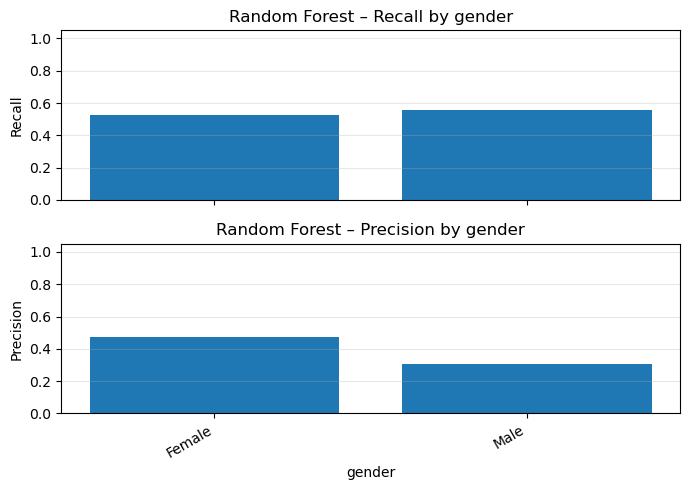

,group,n,recall,precision,TP,FP,FN,TN
0,Female,126,0.526,0.476,10,11,9,96
1,Male,252,0.560,0.304,14,32,11,195



Random Forest fairness by ethnicity


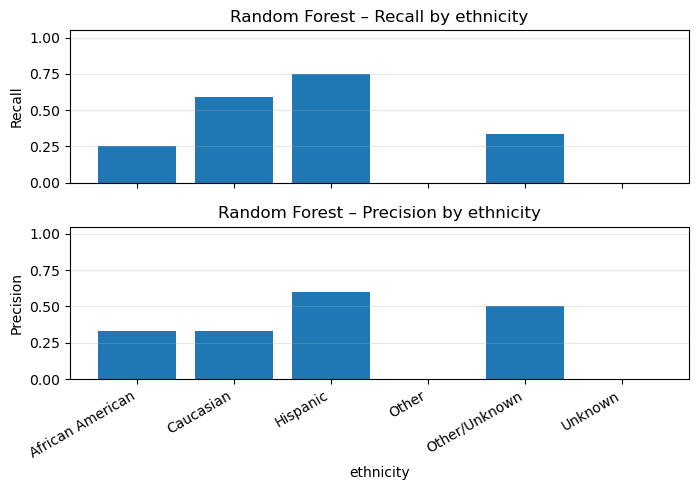

,group,n,recall,precision,TP,FP,FN,TN
0,African American,37,0.250,0.333,1,2,3,31
1,Caucasian,296,0.594,0.333,19,38,13,226
2,Hispanic,22,0.750,0.600,3,2,1,16
3,Other,7,0.000,0.000,0,0,1,6
4,Other/Unknown,13,0.333,0.500,1,1,2,9
5,Unknown,3,0.000,0.000,0,0,0,3



Random Forest fairness by unittype


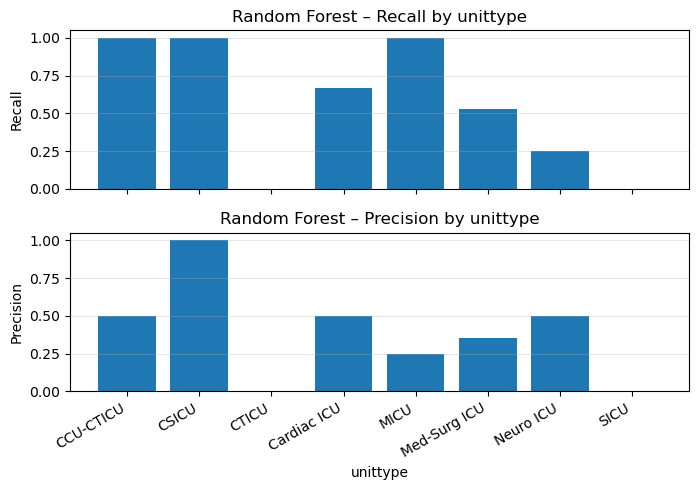

,group,n,recall,precision,TP,FP,FN,TN
0,CCU-CTICU,7,1.000,0.500,1,1,0,5
1,CSICU,17,1.000,1.000,1,0,0,16
2,CTICU,4,0.000,0.000,0,1,0,3
3,Cardiac ICU,20,0.667,0.500,2,2,1,15
4,MICU,22,1.000,0.250,2,6,0,14
5,Med-Surg ICU,282,0.531,0.354,17,31,15,219
6,Neuro ICU,14,0.250,0.500,1,1,3,9
7,SICU,12,0.000,0.000,0,1,1,10


In [81]:
rf_fair_results = {}

for col in ["gender", "ethnicity", "unittype"]:
    print(f"\nRandom Forest fairness by {col}")
    rf_fair_results[col] = plot_fairness_bars(
        model_name="Random Forest",
        y_true=y_test.values,
        y_pred=rf_test_pred_best,
        fair_df=fair_test,
        group_col=col
    )
    display(rf_fair_results[col])


 XGBoost fairness by gender


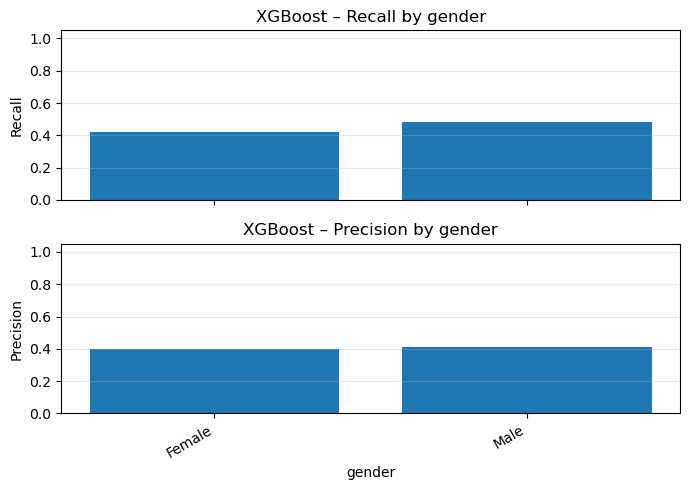

,group,n,recall,precision,TP,FP,FN,TN
0,Female,126,0.421,0.400,8,12,11,95
1,Male,252,0.480,0.414,12,17,13,210



 XGBoost fairness by ethnicity


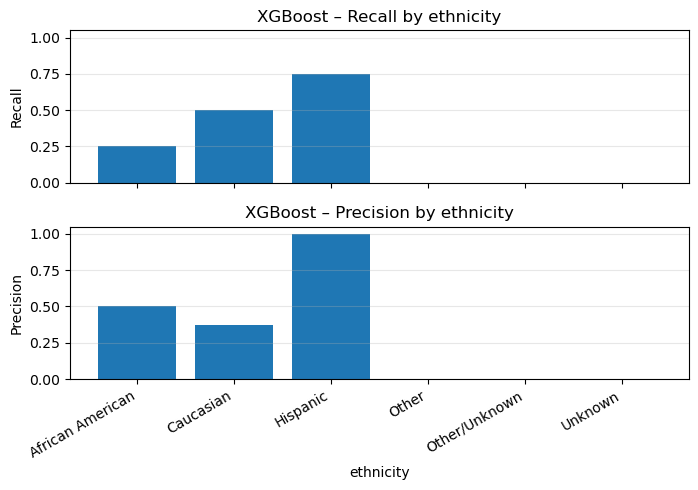

,group,n,recall,precision,TP,FP,FN,TN
0,African American,37,0.25,0.500,1,1,3,32
1,Caucasian,296,0.50,0.372,16,27,16,237
2,Hispanic,22,0.75,1.000,3,0,1,18
3,Other,7,0.00,0.000,0,1,1,5
4,Other/Unknown,13,0.00,0.000,0,0,3,10
5,Unknown,3,0.00,0.000,0,0,0,3



 XGBoost fairness by unittype


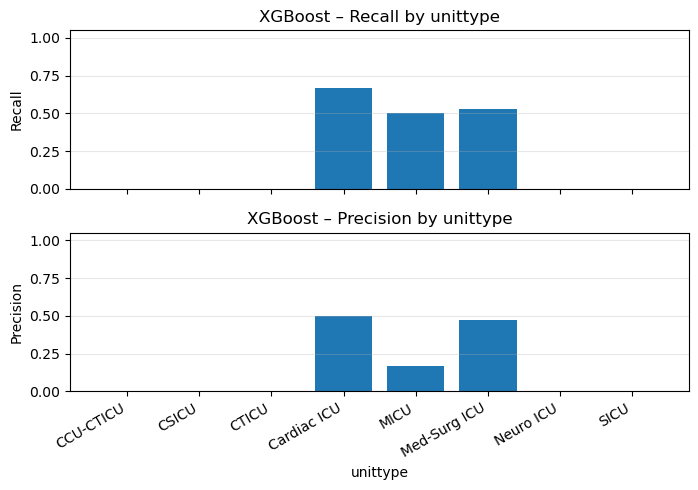

,group,n,recall,precision,TP,FP,FN,TN
0,CCU-CTICU,7,0.000,0.000,0,1,1,5
1,CSICU,17,0.000,0.000,0,0,1,16
2,CTICU,4,0.000,0.000,0,0,0,4
3,Cardiac ICU,20,0.667,0.500,2,2,1,15
4,MICU,22,0.500,0.167,1,5,1,15
5,Med-Surg ICU,282,0.531,0.472,17,19,15,231
6,Neuro ICU,14,0.000,0.000,0,1,4,9
7,SICU,12,0.000,0.000,0,1,1,10


In [83]:
xgb_fair_results = {}

for col in ["gender", "ethnicity", "unittype"]:
    print(f"\n XGBoost fairness by {col}")
    xgb_fair_results[col] = plot_fairness_bars(
        model_name="XGBoost",
        y_true=y_test.values,
        y_pred=xgb_test_pred_best,
        fair_df=fair_test,
        group_col=col
    )
    display(xgb_fair_results[col])

**notes:**
Overall metrics: RF and XGB have similar AUROC; XGB usually has slightly better precision at similar recall after threshold tuning.

Fairness trend:
- For large groups (male/female, Caucasian, Med-Surg ICU), XGB gives a more balanced trade-off (good recall with fewer false positives).
- For tiny groups, RF sometimes gives non-zero recall where XGB does not, but those numbers are unstable 


**gender fairness**

Takeaway: Gaps between male vs female are small in both models; XGB looks slightly more “even” across gender, RF is a bit more “alarm-happy,” especially for males
- RF is a bit more sensitive for both genders (higher recall), but especially noisy for males (lots of false positives → low precision).
- XGB drops recall for both genders but balances precision between men and women.

RF
- Female: recall 0.53, precision 0.48
- Male: recall 0.56, precision 0.30

XGB
- Female: recall 0.42, precision 0.40
- Male: recall 0.48, precision 0.41


**ethnicity fairness**

Takeaway : Both models catch Hispanics the most and African American patients the least (in terms of recall). XGB generally has higher precision (fewer false alarms) for each ethnicity, with similar recall to RF. Very small groups (“Other”, “Other/Unknown”, “Unknown”) are unstable: a few patients, sometimes 0 recall. 

note: maybe.. focus on groups with enough patients (African American, Caucasian, Hispanic)???

RF
- African American: recall 0.25, precision 0.33
- Caucasian: recall 0.59, precision 0.33
- Hispanic: recall 0.75, precision 0.60

XGB
- African American: recall 0.25, precision 0.50
- Caucasian: recall 0.50, precision 0.37
- Hispanic: recall 0.75, precision 1.00 (no FPs here, but n is small)


**ICU unit type fairness**

Takeaway : On the main unit (Med-Surg), both models catch about the same proportion of bad outcomes, but XGB makes fewer false alarms. For the tiny units, RF at least sometimes flags positives; XGB can basically ignore them (0 recall), but that might just be small-sample noise.

note: Med-Surg ICU (most of the data).

RF (Med-Surg)
- Recall 0.53, precision 0.35

XGBoost (Med-Surg)
- Recall 0.53, precision 0.47

Smaller units
- RF often has non-zero recall (e.g., CCU-CTICU, CSICU, MICU).
- XGB sometimes has 0 recall in tiny units (e.g., CCU-CTICU, CSICU, Neuro ICU), meaning it almost never flags positives there

------